Experiment 6: Generative Adversarial Networks (GANs) for Image
Generation
Students will understand and implement a Generative Adversarial Network
(GAN) for generating new images similar to a training set, such as the MNIST
dataset.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

# Reproducibility
tf.random.set_seed(42)

# Hyperparameters
LATENT_DIM = 100
BATCH_SIZE = 64
EPOCHS = 150

(x_train, y_train), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize to [-1, 1]
x_train = (x_train.astype('float32') - 127.5) / 127.5
x_train = np.expand_dims(x_train, axis=-1)

dataset = tf.data.Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(60000).batch(BATCH_SIZE)


def build_discriminator():
    model = tf.keras.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),
        layers.Dense(512),
        layers.LeakyReLU(0.2),
        layers.Dense(256),
        layers.LeakyReLU(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    return model


generator = build_generator()
discriminator = build_discriminator()

cross_entropy = tf.keras.losses.BinaryCrossentropy()

def d_loss(real, fake):
    real_loss = cross_entropy(tf.ones_like(real), real)
    fake_loss = cross_entropy(tf.zeros_like(fake), fake)
    return real_loss + fake_loss

def g_loss(fake):
    return cross_entropy(tf.ones_like(fake), fake)

g_optimizer = tf.keras.optimizers.Adam(0.0002)
d_optimizer = tf.keras.optimizers.Adam(0.0002)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
@tf.function
def train_step(real_images):
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = generator(noise)

        real_output = discriminator(real_images)
        fake_output = discriminator(fake_images)

        loss_g = g_loss(fake_output)
        loss_d = d_loss(real_output, fake_output)

    grads_g = gen_tape.gradient(loss_g, generator.trainable_variables)
    grads_d = disc_tape.gradient(loss_d, discriminator.trainable_variables)

    g_optimizer.apply_gradients(zip(grads_g, generator.trainable_variables))
    d_optimizer.apply_gradients(zip(grads_d, discriminator.trainable_variables))

    return loss_g, loss_d

for epoch in range(EPOCHS):
    for image_batch in dataset:
        loss_g, loss_d = train_step(image_batch)

    print(f"Epoch {epoch+1}: G={loss_g:.4f}, D={loss_d:.4f}")

Epoch 1: G=11.1701, D=0.0046
Epoch 2: G=1.9311, D=0.2243
Epoch 3: G=8.3575, D=0.0436
Epoch 4: G=10.0730, D=0.0644
Epoch 5: G=4.5144, D=0.0398
Epoch 6: G=7.3715, D=0.0142
Epoch 7: G=11.6458, D=0.2202
Epoch 8: G=5.1374, D=0.0433
Epoch 9: G=6.4327, D=0.0231
Epoch 10: G=4.9418, D=0.3601
Epoch 11: G=4.5486, D=0.1345
Epoch 12: G=4.7925, D=0.3593
Epoch 13: G=3.5769, D=0.1114
Epoch 14: G=6.1822, D=0.2181
Epoch 15: G=3.5111, D=0.2157
Epoch 16: G=6.6635, D=0.2519
Epoch 17: G=2.8936, D=0.4141
Epoch 18: G=2.1613, D=0.4215
Epoch 19: G=4.3203, D=0.1848
Epoch 20: G=3.3643, D=0.4477
Epoch 21: G=3.2740, D=0.4820
Epoch 22: G=3.2280, D=0.1902
Epoch 23: G=3.1567, D=0.5682
Epoch 24: G=3.2177, D=0.5369
Epoch 25: G=3.7437, D=0.5960
Epoch 26: G=2.6613, D=0.4171
Epoch 27: G=2.3770, D=0.3254
Epoch 28: G=2.9135, D=0.5534
Epoch 29: G=2.7813, D=0.4825
Epoch 30: G=1.4430, D=0.7987
Epoch 31: G=1.8103, D=0.6075
Epoch 32: G=3.2088, D=0.4187
Epoch 33: G=2.2272, D=0.3640
Epoch 34: G=1.8218, D=0.9303
Epoch 35: G=1.8792, 

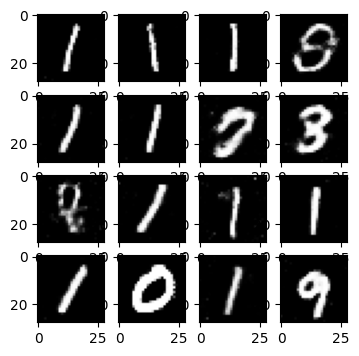

In [ ]:
def generate_images(model, n=16):
    noise = tf.random.normal([n, LATENT_DIM])
    images = model(noise, training=False)

    plt.figure(figsize=(4,4))
    for i in range(n):
        plt.subplot(4,4,i+1)
        plt.imshow(images[i,:,:,0]*127.5+127.5, cmap='gray')
        plt.axis('On')
    plt.show()

generate_images(generator)

In [ ]:
from PIL import Image

os.makedirs("fake_images", exist_ok=True)
os.makedirs("real_images", exist_ok=True)

# Save fake images
for i in range(1000):
    noise = tf.random.normal([1, LATENT_DIM])
    img = generator(noise)[0]
    img = ((img + 1) * 127.5).numpy().astype(np.uint8).squeeze()
    Image.fromarray(img).save(f"fake_images/{i}.png")

# Save real images
for i in range(1000):
    img = ((x_train[i] + 1) * 127.5).astype(np.uint8).squeeze()
    Image.fromarray(img).save(f"real_images/{i}.png")

In [ ]:
from scipy.linalg import sqrtm
import tensorflow as tf
import numpy as np

# Load InceptionV3
inception = tf.keras.applications.InceptionV3(
    include_top=False,
    pooling='avg',
    input_shape=(299, 299, 3)
)

def preprocess(images):
    images = tf.image.resize(images, (299, 299))
    images = tf.image.grayscale_to_rgb(images)
    return tf.keras.applications.inception_v3.preprocess_input(images)

def get_features(images, batch_size=100):
    features = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i+batch_size]
        batch = preprocess(batch)
        pred = inception(batch, training=False)
        features.append(pred.numpy())
    return np.vstack(features)

def calculate_fid(real_images, fake_images):
    act1 = get_features(real_images)
    act2 = get_features(fake_images)

    mu1, sigma1 = act1.mean(axis=0), np.cov(act1, rowvar=False)
    mu2, sigma2 = act2.mean(axis=0), np.cov(act2, rowvar=False)

    ssdiff = np.sum((mu1 - mu2)**2)

    covmean = sqrtm(sigma1 @ sigma2)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = ssdiff + np.trace(sigma1 + sigma2 - 2 * covmean)
    return fid

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
real_images = x_train[:1000]

noise = tf.random.normal([1000, LATENT_DIM])
fake_images = generator(noise)

fid_score = calculate_fid(real_images, fake_images)

print("FID Score:", fid_score)

FID Score: 0.8935822628183798


/tmp/ipykernel_599/3386209047.py:35: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = sqrtm(sigma1 @ sigma2)
